# Dubai Real Estate 2025 - Spatial and Structural Exploratory Analysis
This notebook investigates the spatial and structural characteristics of Dubai's 2025 residential transaction market. The analysis examines how transaction activity is distributed across areas and how property size, property type and bedroom configuration vary with different levels of market activity.

The objective is not only to describe these patterns, but also to test whether relationships observed at the aggregate level persist after accounting for important differences in property composition.

## Workflow and Results
**1. Transaction Distribution Across Areas:** Examines how residential transaction activity is distributed across Dubai's 122 areas.  
→ Transaction activity is highly concentrated: **16 areas (13.1%) account for over 61.5% of all transactions**, while the least-active half of areas account for only **0.84%**. The Gini coefficient (**0.751**) and Lorenz curve confirm the substantial inequality in transaction activity across areas.  

**2. Property Size by Area:** Tests whether property size varies systematically with transaction activity.  
→ Both median and mean property sizes decrease as activity increases (**ρ = −0.676** and **ρ = −0.613**, respectively; both **p < 0.001**).
Absolute size variability shows no statistically significant relationship with activity, while relative variability exhibits only a weak positive association (**ρ  = 0.206, p = 0.047**).

**3. Property Type Composition:** Examines if the Unit-Villa composition changes with transaction activity.  
→ High-activity areas are dominated by Units ( **≈ 86%** of Unit share), while low-activity areas are predominantly Villa-based (**≈ 93%** of Villa share). Unit share is strongly positively associated with transaction activity (**ρ = 0.648, p < 0.001**). In addition, **51 of 122 areas (41.8%)** record no Unit transactions.

**4. Within-Type Property Size Analysis:** Tests whether the negative size-activity relationship persists when analysing Units and Villas separately.   
→ The relationship persists within both property types. Median property size is negatively associated with type-specific transaction activity for both Units (**ρ = −0.514**) and Villas (**ρ = −0.551**), with **p < 0.001** in both cases. This indicates that differences in Unit–Villa composition do not fully explain the aggregate size–activity relationship.

**5. Room-Type Composition:** Explores how bedroom configuration variees with transaction activity and whether the pattern remains within the Unit segment.  
→ Across all properties, Studio, one-bedroom, and two-bedroom shares increase with transaction activity, while the share of 4+ B/R properties decreases. The average bedroom-category score shows a strong negative association with activity (**ρ = −0.794, p < 0.001**).  
→ The pattern also remains within Units: higher Unit transaction activity is associated with greater Studio and one-bedroom shares and lower two- and three-bedroom shares. This shows that the bedroom-composition gradient is not explained solely by the changing Unit–Villa composition of areas.

### Analytical Scope by Section
Two dataset versions are used to balance representational completeness with the stability of area-level statistics:

- **Full Dataset (`df`)** — Includes all 122 areas and is used for descriptive and compositional analyses, including Sections 1, 3, and 5.

- **Filtered Dataset (`df_clean`)** — Excludes 28 areas with fewer than 10 transactions each. These areas represent approximately 23% of areas but only 0.05% of transactions. The filtered dataset is used for area-level size and correlation analyses in Sections 2 and 4, where estimates based on extremely small samples could be unstable.

This approach retains the full market structure where appropriate while reducing the influence of sparsely represented areas in inferential comparisons.

## Summary of Insights
**- Transaction Concentration:** Residential transaction activity is highly uneven across Dubai's areas, with a relatively small number of communities accounting for most transactions.

**- Property Size Gradient:** More active areas tend to contain smaller residential properties, and this relationship remains visible within both Units and Villas.

**- Property-Type Structure:** Unit share increases strongly with transaction activity, while lower-activity areas are substantially more likely to be Villa-dominated or entirely Villa-based.

**- Bedroom-Configuration Gradient:** More active areas tend to have transaction mixes concentrated in smaller bedroom configurations. This pattern persists within Units, indicating that it is not solely a consequence of differences in property type.

Together, these findings establish the main structural patterns of Dubai's 2025 residential transaction market and provide a foundation for the subsequent price analysis and predictive modelling stages of the project.

# Libraries

In [3]:
import pandas as pd               # Data Manipulation
import numpy as np                # Data Manipulation
import matplotlib.pyplot as plt   # Data Visualization
import seaborn as sns             # Data Visualization
sns.set()

from scipy.stats import spearmanr # Spearman Correlation Statistics

# Data
The cleaned and validated dataset is stored in the 'data/interim' directory within this repository. The path has been included to run the code without further modifications.

In [5]:
# Importing the data
raw = pd.read_csv('real_estate_2025.csv')
df = raw.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220918 entries, 0 to 220917
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    220918 non-null  object 
 1   transaction_type  220918 non-null  object 
 2   date              220918 non-null  object 
 3   property_type     220918 non-null  object 
 4   registration      220918 non-null  object 
 5   area              220918 non-null  object 
 6   building          194538 non-null  object 
 7   project           197958 non-null  object 
 8   master_project    194085 non-null  object 
 9   landmark          220918 non-null  object 
 10  metro             220918 non-null  object 
 11  mall              220918 non-null  object 
 12  rooms             220918 non-null  object 
 13  parking           220918 non-null  int64  
 14  size              220918 non-null  float64
 15  price             220918 non-null  float64
 16  metre_price       22

# Functions
Several stages of the 'Spatial and Structural Exploratory Analysis' workflow rely on reusable helper functions. To keep the notebook focused on methodology, validation and results, these functions are defined separately in 'spatial_utils.py', located in the repository's 'src/functions' directory (https://github.com/DandeLC/Dubai-Real-Estate-Price-Analysis/blob/main/src/functions/spatial_utils.py).

The following code adds this directory to the Python path and imports the required utilities.

In [7]:
import os
import sys

functions_path = os.path.abspath(
    os.path.join('..', 'src', 'functions')
)

if functions_path not in sys.path:
    sys.path.append(functions_path)

from spatial_utils import (
    format_pvalue,
    gini,
    corr_summary,
    simplify_rooms,
    create_type_size_stats,
    plot_grouped_share
)

# 1. Transaction Distribution Across Areas
The analysis begins by examining how residential transaction activity is distributed across Dubai's 122 areas. Area-level transaction counts are used to identify highly active and sparsely represented communities and to quantify the overall concentration of market activity.

## 1.0. Key Findings
Residential transaction activity is highly concentrated across Dubai's areas. **Sixteen areas (13% of the total)** recorded at least 5,000 transactions each and collectively account for **61.5% of all transactions**. In contrast, the **least-active half** of areas together account for only **0.84% of transaction activity**.

At the extreme lower end of the distribution, 28 areas (23.0% of all areas) recorded fewer than 10 transactions each, collectively representing only 0.05% of the dataset.

A Gini coefficient of **0.751**, supported by the Lorenz curve, further demonstrates the substantial inequality in transaction activity across areas. These findings indicate that Dubai's 2025 residential transaction market is dominated by a relatively small number of highly active communities.

## 1.1. Initial Overview
An area-level summary is constructed by counting the number of transactions recorded in each of Dubai's 122 areas. Each area's share of total transactions and cumulative transaction share are also calculated to examine the distribution of market activity.

Summary statistics and the most and least active areas are inspected to provide an initial view of the degree of concentration across communities.

In [10]:
# Group by area and count transactions
area_summary = (
    df.groupby('area')
      .size()
      .reset_index(name='transaction_count')
      .sort_values(by='transaction_count', ascending=False)
      .reset_index(drop=True)
)

# Individual percentages
area_summary['transactions_pct'] = (area_summary['transaction_count']/len(df)*100)

# Cumulative percentages
area_summary['cumulative_pct'] = area_summary['transactions_pct'].cumsum()

# Useful metrics
total_areas = len(area_summary)
total_transactions = len(df)

In [11]:
print(area_summary['transaction_count'].describe())

count      122.000000
mean      1810.803279
std       3264.421778
min          1.000000
25%         11.250000
50%        199.000000
75%       2327.250000
max      21467.000000
Name: transaction_count, dtype: float64


In [12]:
# Most active areas
print('The 10 most active areas:')
display(area_summary.head(10))

The 10 most active areas:


,area,transaction_count,transactions_pct,cumulative_pct
0,Al Barsha South Fourth,21467,9.717180,9.717180
1,Business Bay,13134,5.945192,15.662372
2,Wadi Al Safa 5,12854,5.818448,21.480821
3,Madinat Al Mataar,11091,5.020415,26.501236
4,Marsa Dubai,9696,4.388959,30.890195
5,Jabal Ali First,7672,3.472782,34.362976
6,Me'Aisem First,6682,3.024652,37.387628
7,Wadi Al Safa 3,6563,2.970786,40.358414
8,Al Hebiah First,6555,2.967164,43.325578
9,Hadaeq Sheikh Mohammed Bin Rashid,5980,2.706887,46.032465


In [13]:
# Check contribution of 50 bottom areas
bottom_half = area_summary.tail(total_areas // 2)

bottom_half_transactions = bottom_half['transaction_count'].sum()
bottom_half_pct = (
    bottom_half_transactions / total_transactions * 100
)

print(
    f"Bottom 50% of areas: {len(bottom_half)} areas\n"
    f"Transactions: {bottom_half_transactions:,} "
    f"({bottom_half_pct:.2f}% of total)"
)

Bottom 50% of areas: 61 areas
Transactions: 1,854 (0.84% of total)


## 1.2. High-Activity Areas
For descriptive purposes, areas recording at least 5,000 transactions are classified as high-activity areas, allowing the concentration of transactions among the most active communities to be quantified.

In [15]:
HIGH_ACTIVITY_THRESHOLD = 5000

In [16]:
# Extraction
high_activity_areas = area_summary[area_summary['transaction_count'] >= HIGH_ACTIVITY_THRESHOLD]
n_high_areas = len(high_activity_areas)
n_high_transactions = high_activity_areas['transaction_count'].sum()

# Percentages
pct_areas_high = 100 * n_high_areas / total_areas
pct_trans_high = 100 * n_high_transactions / total_transactions

In [17]:
# Results
print('High-Activity areas:')
print(f'Areas with 5000+ transactions: {n_high_areas} ({pct_areas_high:.2f}% of total areas)')
print(f'Transactions in those areas: {n_high_transactions} ({pct_trans_high:.2f}% of total transactions)')

High-Activity areas:
Areas with 5000+ transactions: 16 (13.11% of total areas)
Transactions in those areas: 135895 (61.51% of total transactions)


## 1.3. Low-Activity Areas
At the opposite end of the distribution, areas with fewer than 10 recorded transactions are identified to assess the prevalence and transaction-level relevance of sparsely represented communities.

These areas are subsequently excluded from inferential analyses based on area-level summary statistics, where very small sample sizes could produce unstable estimates.

In [19]:
LOW_ACTIVITY_THRESHOLD = 10

In [20]:
# Extraction
low_activity_areas = area_summary[area_summary['transaction_count'] < LOW_ACTIVITY_THRESHOLD]
n_low_areas = len(low_activity_areas)
n_low_transactions = low_activity_areas['transaction_count'].sum()

# Percentages
pct_areas_low = 100 * n_low_areas / total_areas
pct_trans_low = 100 * n_low_transactions / total_transactions

In [21]:
# Results
print('Low-Activity areas:')
print(f'Areas with <10 transactions: {n_low_areas} ({pct_areas_low:.2f}% of total areas)')
print(f'Transactions in those areas: {n_low_transactions} ({pct_trans_low:.2f}% of total transactions)')

Low-Activity areas:
Areas with <10 transactions: 28 (22.95% of total areas)
Transactions in those areas: 105 (0.05% of total transactions)


## 1.4. Inequality Analysis
The Gini coefficient, which ranges from 0 (perfect equality) to 1 (perfect inequality), is calculated on transaction counts per area to quantify the concentration of real-estate activity. The resulting value of **0.751** indicates a strong disparity in transaction distribution, meaning that most property sales are concentrated within a small number of communities, further reinforcing the evidence of concentration previously observed.

The accompanying Lorenz curve provides a graphical representation of this inequality, plotting the cumulative share of transactions against the cumulative share of areas. The sharp curvature of the line relative to the diagonal of equality visually confirms the high concentration indicated by the Gini coefficient.

In [23]:
# Calculating the Gini coefficient
gini_area = gini(area_summary['transaction_count'])
print(f"Gini coefficient (transaction concentration): {gini_area:.3f}")

Gini coefficient (transaction concentration): 0.751


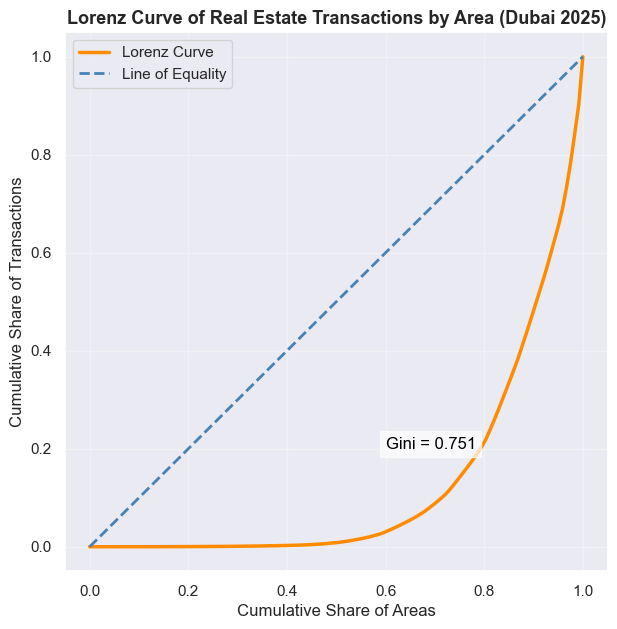

In [24]:
# Sort transaction counts ascending (Lorenz curves always start from smallest to largest)
values = np.sort(area_summary['transaction_count'].values)

# Cumulative share of transactions
cum_values = np.insert(np.cumsum(values) / values.sum(),0,0)

# Cumulative share of areas
cum_areas = np.insert(np.arange(1, len(values) + 1) / len(values),0,0)

# --- Plot ---
plt.figure(figsize=(7, 7))
plt.plot(cum_areas, cum_values, label='Lorenz Curve', color='darkorange', linewidth=2.5)
plt.plot([0, 1], [0, 1], label='Line of Equality', color='steelblue', linestyle='--', linewidth=2)

# Add Gini annotation (if you already calculated it)
plt.text(0.6, 0.2, f"Gini = {gini_area:.3f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.7))

# Titles and labels
plt.title('Lorenz Curve of Real Estate Transactions by Area (Dubai 2025)', fontsize=13, weight='bold')
plt.xlabel('Cumulative Share of Areas')
plt.ylabel('Cumulative Share of Transactions')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 1.5. Removal of Lowest Activity Areas
Areas with less than 10 recorded transactions are excluded from subsequent area-level inferential analyses. These 28 areas represent approximately 23% of all areas but only 0.05% of transactions, meaning their exclusion has a negligible effect on transaction-level coverage while reducing the influence of unstable area-level statistics based on very small samples.

The full dataset (df) is retained for descriptive and compositional analyses, while the filtered dataset (df_clean) is used where reliable area-level summary statistics and correlations are required.

In [26]:
# Filter areas with at least 10 transactions
valid_areas = area_summary.loc[area_summary['transaction_count'] >= 10, 'area']
df_clean = df[df['area'].isin(valid_areas)].copy()
area_summary_clean = area_summary[area_summary['area'].isin(valid_areas)].copy()

In [27]:
df_clean['area'].nunique()

94

# 2. Property Size by Area
Building on the transaction-distribution analysis, this section examines whether areas with greater residential transaction activity tend to contain smaller properties. 

The analysis uses the filtered dataset (df_clean), which excludes areas with fewer than 10 transactions to reduce instability in area-level summary statistics. For each of the remaining 94 areas, transaction activity is compared with median and mean property size, as well as absolute and relative measures of size variability.

## 2.0. Key Findings
Area-level property size shows a strong negative association with transaction activity. Spearman correlations are **ρ = −0.676** for median size and **ρ = −0.613** for mean size (both p < 0.001), indicating that more active areas tend to contain smaller residential properties.

Absolute size variability, measured using the interquartile range, shows only a weak negative association with transaction activity (**ρ = −0.176, p = 0.090**) and is not statistically significant at the conventional 5% level.  
Relative variability (IQR / median) shows a weak positive association with activity (**ρ = 0.206, p = 0.047**). Although the association meets the conventional 5% significance threshold, the effect size is small and the result is close to the significance boundary, so it should be interpreted cautiously.

Overall, the clearest pattern is the strong decline in typical property size as transaction activity increases, while evidence for changes in within-area size variability is comparatively weak.

## 2.1. Property Size and Variability by Transaction Activity
Area-level mean and median property sizes, together with absolute (IQR) and relative (IQR / median) size variability, are plotted against transaction activity.

Because transaction counts differ substantially across areas, the x-axis is displayed on a logarithmic scale to improve visual comparability across the full activity range.

In [30]:
area_size_stats = (
    df_clean.groupby('area')['size']
    .agg(
        transaction_count='count',
        median='median',
        mean='mean',
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

area_size_stats['IQR'] = (
    area_size_stats['q3'] - area_size_stats['q1']
)

area_size_stats['relative_IQR'] = (
    area_size_stats['IQR'] / area_size_stats['median']
)

area_size_stats = (
    area_size_stats
    .sort_values('transaction_count', ascending=False)
    .reset_index(drop=True)
)

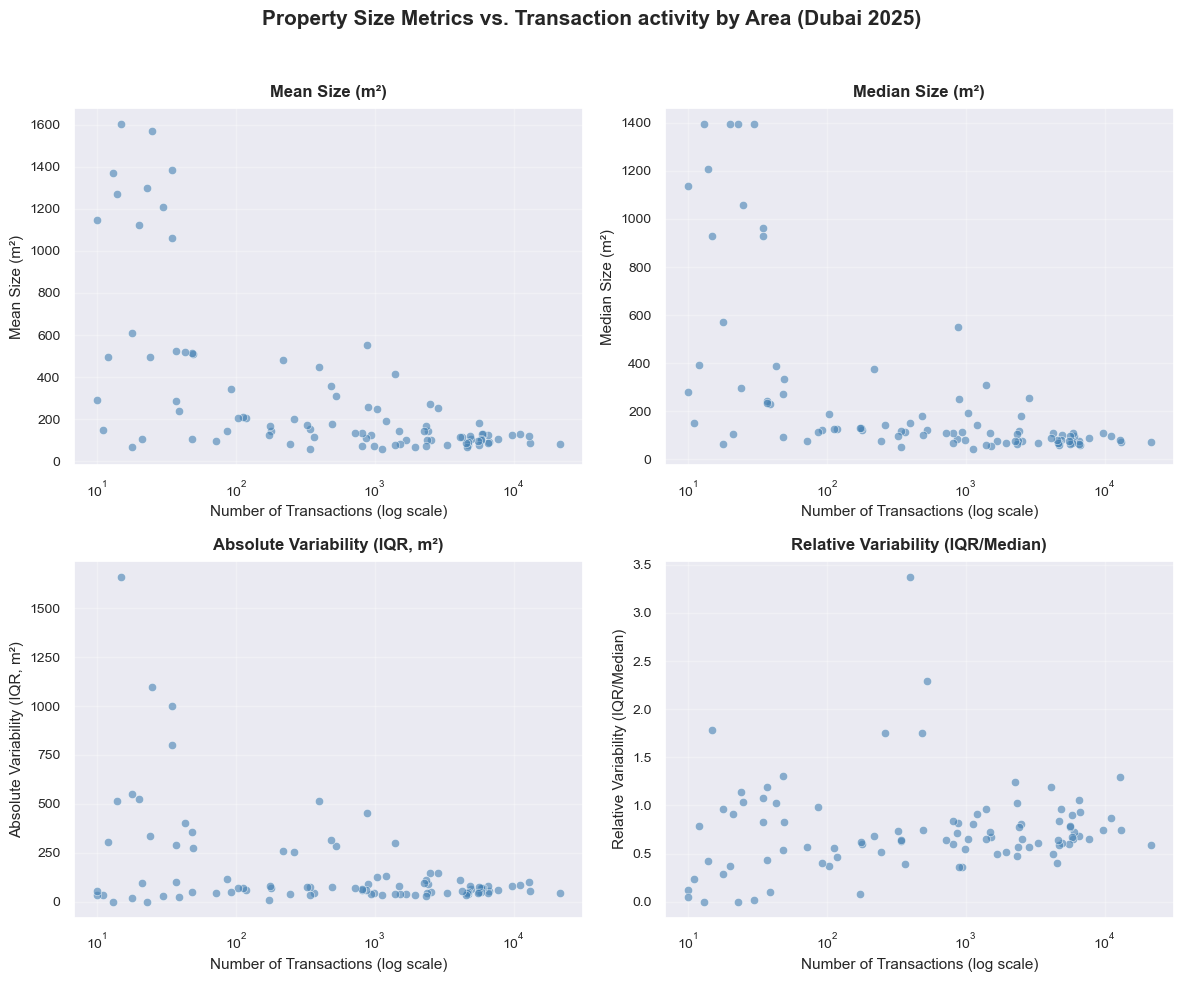

In [31]:
# Comparative scatterplots: Property size metrics vs. transaction activity
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Property Size Metrics vs. Transaction activity by Area (Dubai 2025)", fontsize=15, fontweight='bold')

metrics = {
    "Mean Size (m²)": "mean",
    "Median Size (m²)": "median",
    "Absolute Variability (IQR, m²)": "IQR",
    "Relative Variability (IQR/Median)": "relative_IQR"
}

for ax, (title, col) in zip(axes.flat, metrics.items()):
    ax.scatter(
        area_size_stats['transaction_count'],
        area_size_stats[col],
        alpha=0.6,
        color='steelblue',
        edgecolor='white',
        linewidth=0.5
    )
    ax.set_xscale('log')
    ax.set_xlabel("Number of Transactions (log scale)", fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='semibold', pad=8)
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 2.2. Spearman Correlation
Spearman rank correlation is used to quantify the association between transaction activity and each property-size metric. This non-parametric measure is appropriate because transaction counts are highly uneven across areas and the relationships are not assumed to be linear.

In [33]:
size_metrics = {
    'Median Size': 'median',
    'Mean Size': 'mean',
    'Absolute Variability (IQR)': 'IQR',
    'Relative Variability (IQR/Median)': 'relative_IQR'
}

correlation_results = []

for metric_name, column in size_metrics.items():
    rho, p_value = spearmanr(
        area_size_stats['transaction_count'],
        area_size_stats[column]
    )

    correlation_results.append({
        'Metric': metric_name,
        'Spearman rho': rho,
        'p-value': p_value
    })

correlation_df = pd.DataFrame(correlation_results)

display(
    correlation_df.style.format({
        'Spearman rho': '{:.3f}',
        'p-value': format_pvalue
    })
)

,Metric,Spearman rho,p-value
0,Median Size,-0.676,<0.001
1,Mean Size,-0.613,<0.001
2,Absolute Variability (IQR),-0.176,0.090
3,Relative Variability (IQR/Median),0.206,0.047


# 3. Property Type Composition
To investigate whether the relationship between transaction activity and property size is partly associated with differences in housing composition, this section examines the share of Units and Villas across areas with different levels of transaction activity.

Areas are divided into three activity tertiles according to transaction count. These groups contain approximately equal numbers of areas rather than equal numbers of transactions. Because transaction activity is highly concentrated, as established in Section 1, the high-activity tertile consequently represents a disproportionate share of total transactions.

The tertile comparison is therefore used to examine how the typical area-level property composition changes across different levels of market activity. Each area receives equal weight within its tertile, independently of its transaction activity. Spearman correlation is subsequently used to assess the continuous area-level relationship between Unit share and transaction activity.

## 3.0. Key Findings
Property-type composition varies substantially with area transaction activity. Areas in the high-activity tertile have an average Unit share of approximately **86%**, while areas in the low-activity tertile are predominantly composed of Villas, with an average Villa share of approximately **93%**. Medium-activity areas display a more balanced composition, with approximately **65% Units and 35% Villas**.

The continuous area-level analysis supports this pattern: Unit share is strongly positively associated with transaction activity (**Spearman ρ = 0.648, p < 0.001**), indicating that more active areas tend to have a greater proportion of Unit transactions.

Villa-exclusive areas are also common. **51 of 122 areas (41.8%)** record no Unit transactions. Most of these communities have relatively low transaction activity, although several villa-exclusive areas record hundreds or even thousands of transactions.

Notably, all 28 areas identified in Section 1 with fewer than 10 transactions are found to be villa-exclusive.

Overall, the results reveal a clear structural relationship between property type and transaction activity: highly active areas tend to be Unit-dominated, whereas lower-activity areas are substantially more likely to be Villa-dominated.

## 3.1. Property Type by Activity Tertile
For each area, the percentage of transactions corresponding to Units and Villas is calculated. Areas are then divided into low-, medium-, and high-activity tertiles based on their total transaction count.

The bar chart displays the mean area-level property-type share within each tertile. Because areas rather than individual transactions are averaged, each community contributes equally to its activity group regardless of transaction activity.

A summary of the number of areas, transaction-count range, median activity, and share of total transactions represented by each tertile is also displayed to provide context for the substantial imbalance in transaction activity across the three groups.

Spearman correlation is subsequently used to quantify the continuous relationship between Unit share and transaction activity across all areas. The corresponding scatterplot visualizes this relationship at the individual-area level and reveals a substantial concentration of areas with 0% Unit share, particularly among lower-activity communities. This pattern motivates the closer examination of villa-exclusive areas in the following subsection.

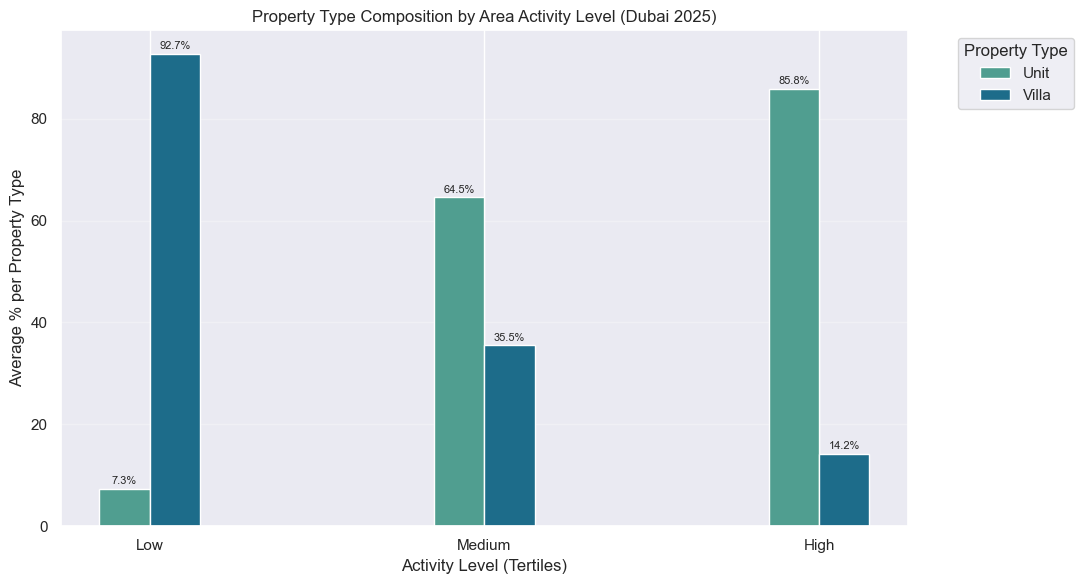

In [36]:
# Displaying combined bar chart
area_property_share, property_type_summary = plot_grouped_share(
    df=df,
    category_col='property_type',
    category_order=['Unit', 'Villa'],
    area_summary=area_summary,
    title='Property Type Composition by Area Activity Level (Dubai 2025)',
    ylabel='Average % per Property Type'
)

In [37]:
activity_summary = (
    area_property_share
    .groupby('activity_group', observed=False)
    .agg(
        areas=('area', 'count'),
        min_transactions=('transaction_count', 'min'),
        median_transactions=('transaction_count', 'median'),
        max_transactions=('transaction_count', 'max'),
        total_transactions=('transaction_count', 'sum')
    )
)

activity_summary['transaction_share_pct'] = (
    activity_summary['total_transactions']
    / activity_summary['total_transactions'].sum()
    * 100
)

display(
    activity_summary.style.format({
        'median_transactions': '{:,.0f}',
        'transaction_share_pct': '{:.2f}%'
    })
)

,areas,min_transactions,median_transactions,max_transactions,total_transactions,transaction_share_pct
activity_group,,,,,,
Low,41,1,5,24,314,0.14%
Medium,40,25,199,1040,13488,6.11%
High,41,1121,"4,627",21467,207116,93.75%


In [38]:
# Spearman correlation
rho_unit, pval_unit = spearmanr(area_property_share['Unit'], area_property_share['transaction_count'])

print(f"Spearman correlation between unit share and number of transactions = {rho_unit:.3f} (p {format_pvalue(pval_unit)})")

Spearman correlation between unit share and number of transactions = 0.648 (p <0.001)


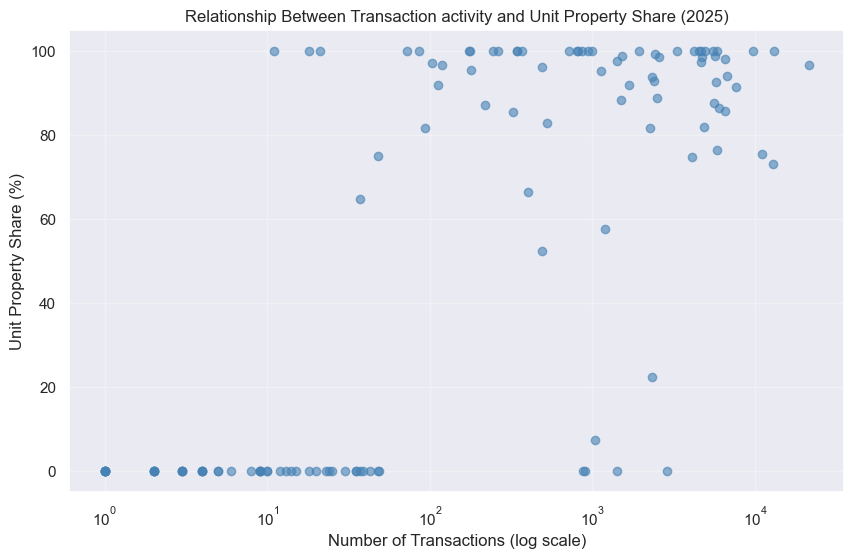

In [39]:
# Scatterplot between unit share and (log) number of transactions
plt.figure(figsize=(10,6))
plt.scatter(area_property_share['transaction_count'],
            area_property_share['Unit'],
            alpha=0.6, color='steelblue')

plt.xscale('log')
plt.xlabel('Number of Transactions (log scale)')
plt.ylabel('Unit Property Share (%)')
plt.title('Relationship Between Transaction activity and Unit Property Share (2025)')
plt.grid(alpha=0.3)
plt.show()

## 3.2. Villa-Exclusive Areas (0% Unit Share)
The area-level composition analysis identifies 51 of 122 areas (41.8%) with no recorded Unit transactions.

Villa exclusivity is strongly concentrated among less-active communities. Most villa-only areas record relatively few transactions, although the pattern is not universal: several villa-exclusive areas record hundreds or even thousands of transactions.

When grouped by transaction activity, the large majority of villa-exclusive areas fall within the lowest activity range, while only a small number exceed 1,000 transactions.

Notably, all 28 areas with fewer than 10 transactions identified in Section 1 are villa-exclusive. This helps explain the strong Villa dominance observed within the low-activity tertile, while also showing that villa-exclusive market structures occur across a broader range of transaction activities.

In [41]:
no_units = area_property_share[area_property_share['Unit'] == 0]

activity_bins = pd.cut(
    no_units['transaction_count'],
    bins=[0, 100, 1000, 5000, np.inf],
    labels=['≤100', '101–1,000', '1,001–5,000', '>5,000']
)

no_units_summary = (
    activity_bins
    .value_counts(sort=False)
    .rename_axis('transaction_range')
    .reset_index(name='areas')
)

# Calculating percentage
only_villa_pct =100*len(no_units)/total_areas

# Displaying results
print(f'Percentage of villa-exclusive areas: {only_villa_pct:.2f}%')
print(no_units_summary)

Percentage of villa-exclusive areas: 41.80%
  transaction_range  areas
0              ≤100     47
1         101–1,000      2
2       1,001–5,000      2
3            >5,000      0


In [42]:
# Check all 28 low activity areas are villa-exclusive
low_activity_properties = (
    df[df['area'].isin(low_activity_areas['area'])]
    .groupby('area')['property_type']
    .unique()
)

display(low_activity_properties.value_counts())

property_type
[Villa]    28
Name: count, dtype: int64

In [43]:
no_units.sort_values('transaction_count',ascending=False).head()

,area,Unit,Villa,transaction_count,activity_group
65,Al Yufrah 1,0.0,100.0,2854,High
49,Al Thanayah Fourth,0.0,100.0,1407,High
63,Al Yelayiss 1,0.0,100.0,895,Medium
116,Wadi Al Safa 6,0.0,100.0,879,Medium
4,Al Bada,0.0,100.0,49,Medium


# 4. Within-Type Property Size Analysis
Sections 2 and 3 identified two related patterns: areas with greater transaction activity tend to contain smaller properties, while highly active areas also tend to have a substantially greater share of Units.

This raises the possibility that the size–activity relationship observed across all properties may be partly explained by differences in property-type composition. To examine this, the relationship between transaction activity and property size is evaluated separately for Units and Villas.

For each property type, size metrics are compared against both type-specific transaction activity and total area transaction activity. This allows the analysis to distinguish between activity within a particular property segment and the broader level of market activity in the area.

## 4.0. Key Findings
The negative relationship between transaction activity and typical property size persists after separating Units and Villas, indicating that the aggregate pattern identified in Section 2 cannot be explained solely by differences in property-type composition.

For **Units**, median property size shows a moderate negative association with both Unit-specific transaction activity (**ρ = −0.514, p < 0.001**) and total area activity (**ρ = −0.518, p < 0.001**).

The relationship is also present among **Villas**. Median Villa size is negatively associated with both Villa-specific transaction activity (**ρ = −0.551, p < 0.001**) and total area activity (**ρ = −0.470, p < 0.001**).

Absolute size variability (`IQR`) shows no statistically significant relationship with activity for either property type. Relative variability (`IQR / median`) shows a weak positive association for Units under both activity measures (**ρ = 0.281, p = 0.018** for Unit-specific activity; **ρ = 0.263, p = 0.027** for total area activity), while no statistically significant relationship is observed for Villas.

Overall, the within-type analysis strengthens the principal finding from Section 2: more active areas tend to contain smaller properties even when Units and Villas are considered separately. Property-type composition therefore contributes to the broader market structure observed in Section 3, but does not fully account for the relationship between transaction activity and property size.

## 4.1. Within-Type Area Statistics
The filtered dataset is separated into Unit and Villa transactions, and area-level size statistics are calculated independently for each property type.

For each area and property type, the analysis calculates transaction count, median and mean property size, and absolute and relative size variability. Total area transaction counts are subsequently added to each type-specific summary, allowing property-size patterns to be evaluated against both type-specific activity and overall area activity.

All Unit areas contain at least 10 Unit transactions. Five Villa areas contain fewer than 10 Villa transactions; a sensitivity analysis excluding these areas produced substantively unchanged results. They are therefore retained in the final analysis to preserve the full set of areas represented in the filtered dataset.

In [46]:
df_units = df_clean[
    df_clean['property_type'] == 'Unit'
].copy()

df_villas = df_clean[
    df_clean['property_type'] == 'Villa'
].copy()

units_stats = create_type_size_stats(
    df_units,
    area_size_stats
)

villa_stats = create_type_size_stats(
    df_villas,
    area_size_stats
)

print(f"Unit areas analyzed: {len(units_stats)}")
print(f"Villa areas analyzed: {len(villa_stats)}")

Unit areas analyzed: 71
Villa areas analyzed: 67


## 4.2. Transaction Activity and Property Size Within Types
Spearman rank correlations are used to evaluate whether the relationships identified across all properties persist when Units and Villas are analyzed independently.

For each property type, area-level median size, absolute variability (IQR), and relative variability (IQR / median) are compared against two measures of transaction activity:

**Type-specific activity:** the number of transactions corresponding to that property type within the area.  
**Total area activity:** the total number of residential transactions recorded in the area.

Results for all properties from Section 2 are included as a benchmark, allowing the aggregate and within-type relationships to be compared directly.

In [48]:
correlation_results = {
    'All properties': corr_summary(
        area_size_stats['transaction_count'],
        area_size_stats
    ),

    'Units - type-specific activity': corr_summary(
        units_stats['transaction_count'],
        units_stats
    ),

    'Units - total area activity': corr_summary(
        units_stats['transaction_count_global'],
        units_stats
    ),

    'Villas - type-specific activity': corr_summary(
        villa_stats['transaction_count'],
        villa_stats
    ),

    'Villas - total area activity': corr_summary(
        villa_stats['transaction_count_global'],
        villa_stats
    )
}

correlation_summary = pd.DataFrame(
    correlation_results
).T

display(
    correlation_summary.style.format({
        'Median Size rho': '{:.3f}',
        'Median Size p-value': format_pvalue,
        'Absolute IQR rho': '{:.3f}',
        'Absolute IQR p-value': format_pvalue,
        'Relative IQR rho': '{:.3f}',
        'Relative IQR p-value': format_pvalue
    })
)

,Median Size rho,Median Size p-value,Absolute IQR rho,Absolute IQR p-value,Relative IQR rho,Relative IQR p-value
All properties,-0.676,<0.001,-0.176,0.090,0.206,0.047
Units - type-specific activity,-0.514,<0.001,-0.192,0.109,0.281,0.018
Units - total area activity,-0.518,<0.001,-0.193,0.106,0.263,0.027
Villas - type-specific activity,-0.551,<0.001,-0.096,0.438,0.169,0.172
Villas - total area activity,-0.470,<0.001,-0.136,0.274,0.010,0.939


# 5. Room-Type Composition
The previous sections identified a clear structural relationship between transaction activity and property characteristics. More active areas tend to contain smaller properties and a substantially greater share of Units, while the negative relationship between transaction activity and property size persists when Units and Villas are analyzed separately.

This section extends the structural analysis by examining bedroom configuration. The objective is to determine whether transaction activity is also associated with the distribution of Studios, one-bedroom, two-bedroom, three-bedroom, and larger properties across areas.

The analysis first examines the overall distribution of bedroom configurations, followed by their relationship with transaction activity across all properties. Units are then analyzed separately to determine whether the observed pattern persists within the dominant property type rather than being explained primarily by differences in the Unit–Villa composition of areas.

Properties classified as PENTHOUSE are excluded because this label does not provide a consistent bedroom count. Bedroom configurations with four or more bedrooms are consolidated into a single 4+ B/R category to reduce sparsity among larger configurations.

## 5.0. Key Findings
Dubai's 2025 residential transactions are strongly concentrated in smaller bedroom configurations. Studios, one-bedroom, and two-bedroom properties collectively account for more than 80% of transactions in the analyzed dataset.

Across all property types, transaction activity is positively associated with the area-level shares of Studios (**ρ = 0.674**), one-bedroom (**ρ = 0.742**), and two-bedroom properties (**ρ = 0.620**), while the share of properties with four or more bedrooms shows a strong negative association (**ρ = −0.607**). The overall bedroom-category score similarly declines as transaction activity increases (**ρ = −0.794, p < 0.001**).

The pattern persists when the analysis is restricted to Units and activity is measured using Unit-specific transaction counts. From the low- to high-activity tertile, the average Studio share increases **from 9.5% to 23.0%** and the one-bedroom share **from 31.9% to 45.0%**, while the two-bedroom share decreases **from 39.4% to 25.2%** and the three-bedroom share **from 16.3% to 6.1%**. The corresponding area-level correlations confirm these relationships.

Overall, bedroom configuration represents an additional structural dimension associated with transaction activity. The within-Unit results indicate that this pattern is not simply a consequence of more active areas containing a greater proportion of Units.

## 5.1. Overall Room-Type Composition
The overall transaction distribution is heavily concentrated in smaller bedroom configurations. One-bedroom properties represent the largest category at approximately **39%** of transactions, followed by two-bedroom properties at approximately **23%** and Studios at approximately **20%**, accounting together for more than **80%** of residential transactions in the analyzed dataset. Three-bedroom and 4+ B/R properties represent substantially smaller shares.

This distribution provides a market-wide benchmark for the area-level analysis that follows. Importantly, these percentages describe the composition of 2025 residential transactions, rather than the composition of Dubai's complete residential housing stock.

In [51]:
df_rooms = df.copy()
df_rooms = df_rooms[df_rooms['rooms'] != 'PENTHOUSE']

In [52]:
df_rooms['rooms_simplified'] = (
    df_rooms['rooms']
    .apply(simplify_rooms)
)

In [53]:
room_dist = (
    df_rooms['rooms_simplified']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Share (%)')
    .reset_index()
    .rename(columns={'index': 'Room Type'})
)
display(room_dist.style.format({'Share (%)': '{:.1f}%'}))


,rooms_simplified,Share (%)
0,1 B/R,38.8%
1,2 B/R,23.1%
2,Studio,20.4%
3,3 B/R,10.4%
4,4+ B/R,7.2%


## 5.2. Room-Type Composition by Activity Tertile
Areas are divided into Low, Medium and High activity tertiles based on total residential transaction counts. For each activity tertile, the mean area-level share of each bedroom category is calculated. The grouped comparison is complemented by Spearman rank correlations between each area's transaction count and the share represented by each bedroom category.

Bedroom composition changes substantially across activity levels. Low-activity areas contain a much greater share of 4+ B/R properties, while Studios and smaller bedroom configurations become increasingly prominent across the Medium and High activity tertiles.

This pattern is consistent with the property-type composition identified in Section 3: low-activity areas are predominantly Villa-based, while the Unit share increases strongly with transaction activity. The bedroom composition therefore partly reflects this broader structural shift toward Units in more active areas.

The continuous analysis supports the same pattern. Studio, one-bedroom and two-bedroom shares are positively associated with transaction activity, while 4+ B/R share shows a strong negative association. The average bedroom-category score also declines substantially as activity increases (**ρ = −0.794, p < 0.001**).

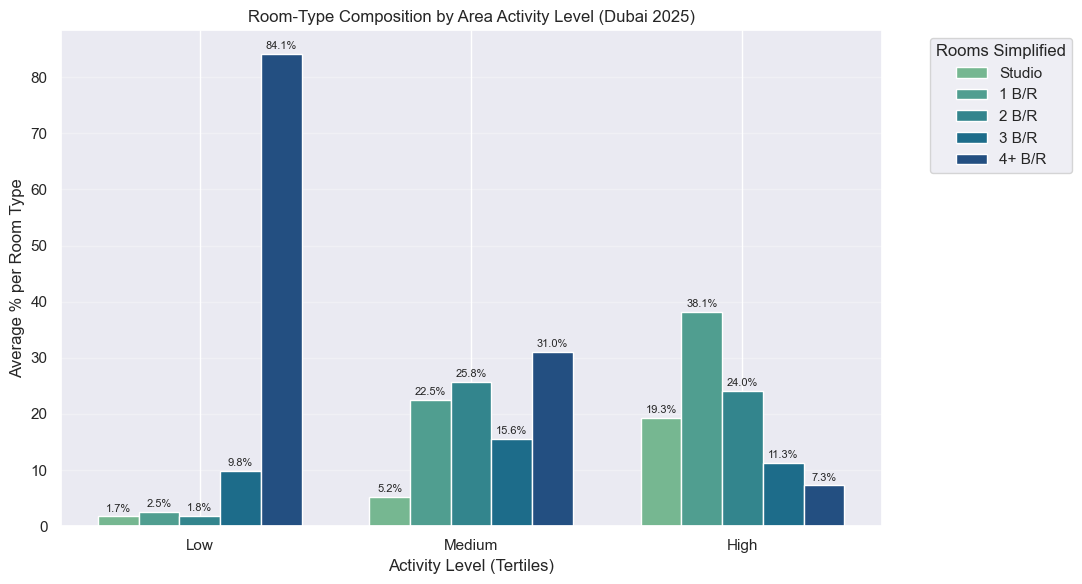

Spearman correlation between rooms_simplified share and transaction activity:


,Category Type,Spearman ρ,p-value
0,Studio,0.674,<0.001
1,1 B/R,0.742,<0.001
2,2 B/R,0.620,<0.001
3,3 B/R,0.346,<0.001
4,4+ B/R,-0.607,<0.001


In [55]:
# Displaying results
area_room_share, area_room_summary = plot_grouped_share(
    df=df_rooms,
    category_col='rooms_simplified',
    category_order=['Studio', '1 B/R', '2 B/R', '3 B/R', '4+ B/R'],
    area_summary=area_summary,
    title='Room-Type Composition by Area Activity Level (Dubai 2025)',
    ylabel='Average % per Room Type',
    show_correlation=True
)

In [56]:
# --- Correlation: average rooms vs. activity ---
room_to_int = {'Studio': 0, '1 B/R': 1, '2 B/R': 2, '3 B/R': 3, '4+ B/R': 4}
df_rooms['room_int'] = (df_rooms['rooms_simplified'].map(room_to_int)).astype('int64')

area_room_stats = df_rooms.groupby('area', observed=False)['room_int'].mean().reset_index(name='avg_rooms')
area_room_stats = area_room_stats.merge(area_summary[['area', 'transaction_count']], on='area')

rho_rooms, p_rooms = spearmanr(area_room_stats['avg_rooms'], area_room_stats['transaction_count'])
print(f"Spearman correlation between average bedroom-category score and transaction activity: ρ = {rho_rooms:.3f}, p {format_pvalue(p_rooms)}")

Spearman correlation between average bedroom-category score and transaction activity: ρ = -0.794, p <0.001


## 5.3. Room-Type Composition by Activity Tertile - Units Only
The relationship identified across all properties may partly reflect differences in property-type composition, since Section 3 showed that highly active areas contain substantially greater shares of Units. To isolate bedroom configuration within this property segment, the analysis is repeated using Unit transactions only. Areas are therefore divided into activity tertiles according to their Unit-specific transaction counts, rather than total residential transaction activity.

The bedroom-composition gradient remains after restricting the analysis to Units. From Low to High Unit-activity areas, Studio and one-bedroom shares increase, while two- and three-bedroom shares decline. The corresponding area-level correlations are statistically significant, confirming that these patterns are not limited to the tertile comparison.

The 4+ B/R share also declines descriptively across the three tertiles, but its continuous relationship with Unit transaction activity is not statistically significant (ρ = 0.122, p = 0.313).

Overall, the Unit-only analysis shows that the bedroom pattern identified in Section 5.2 is not explained solely by the changing Unit–Villa composition of areas; a shift toward smaller bedroom configurations also occurs within the Unit segment itself.

In [58]:
units_rooms = df_rooms[df_rooms['property_type']=='Unit'].copy()

In [59]:
unit_area_summary = (
    units_rooms.groupby('area')
    .size()
    .reset_index(name='transaction_count')
)

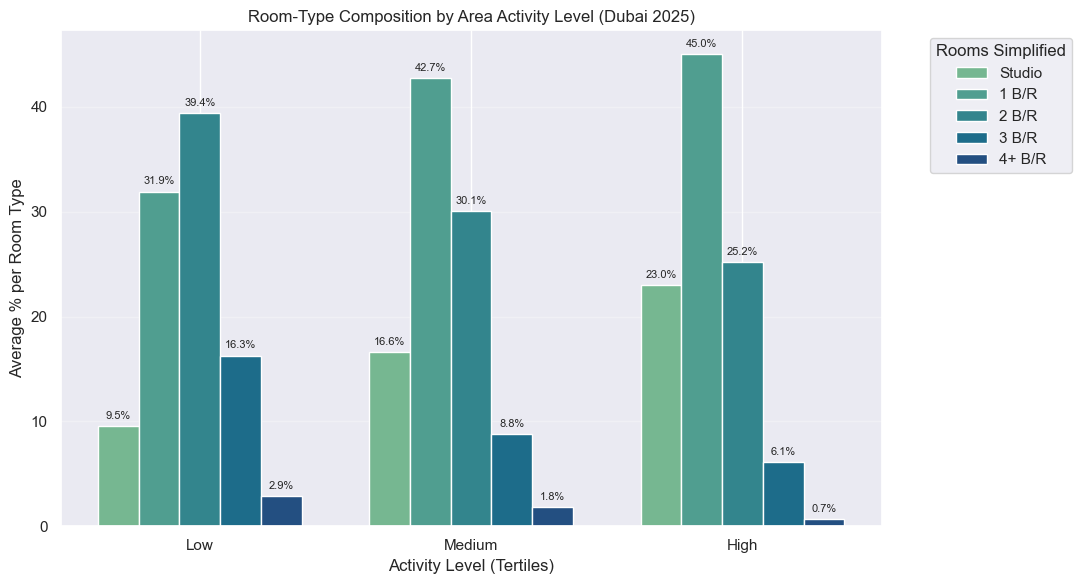

Spearman correlation between rooms_simplified share and transaction activity:


,Category Type,Spearman ρ,p-value
0,Studio,0.402,<0.001
1,1 B/R,0.298,0.012
2,2 B/R,-0.375,0.001
3,3 B/R,-0.375,0.001
4,4+ B/R,0.122,0.313


In [60]:
# Displaying results
units_room_share, units_room_summary = plot_grouped_share(
    df=units_rooms,
    category_col='rooms_simplified',
    category_order=['Studio', '1 B/R', '2 B/R', '3 B/R', '4+ B/R'],
    area_summary=unit_area_summary,
    title='Room-Type Composition by Area Activity Level (Dubai 2025)',
    ylabel='Average % per Room Type',
    show_correlation=True
)